# Classification Using Decision Trees


## Loading Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

sn.set_palette("tab10")

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
# Load the data
path = '/content/drive/MyDrive/Python/decision_tree/SAheart.data'
chd_df = pd.read_csv(path, index_col = [0])

In [10]:
# Sample check the data
chd_df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
row.names,,,,,,,,,,
1,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
2,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
3,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
4,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
5,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


- sbp is blood pressure
- adiposity related to weight and waist size
- famhist
- typea: personality

In [11]:
# Get datatype and d null value information of the data
chd_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 462 entries, 1 to 463
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 39.7+ KB


## EDA

In [12]:
chd_df.describe()

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,138.326840,3.635649,4.740325,25.406732,53.103896,26.044113,17.044394,42.816017,0.346320
std,20.496317,4.593024,2.070909,7.780699,9.817534,4.213680,24.481059,14.608956,0.476313
min,101.000000,0.000000,0.980000,6.740000,13.000000,14.700000,0.000000,15.000000,0.000000
25%,124.000000,0.052500,3.282500,19.775000,47.000000,22.985000,0.510000,31.000000,0.000000
50%,134.000000,2.000000,4.340000,26.115000,53.000000,25.805000,7.510000,45.000000,0.000000
75%,148.000000,5.500000,5.790000,31.227500,60.000000,28.497500,23.892500,55.000000,1.000000
max,218.000000,31.200000,15.330000,42.490000,78.000000,46.580000,147.190000,64.000000,1.000000


In [13]:
#Get chd value count
chd_df['chd'].value_counts()

,count
chd,
0,302
1,160


<Axes: xlabel='chd', ylabel='count'>

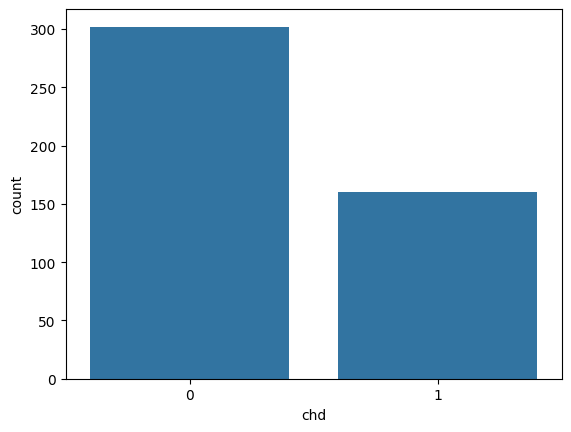

In [14]:
#plot chd
sn.countplot(x = 'chd', data = chd_df)

<Axes: xlabel='famhist', ylabel='count'>

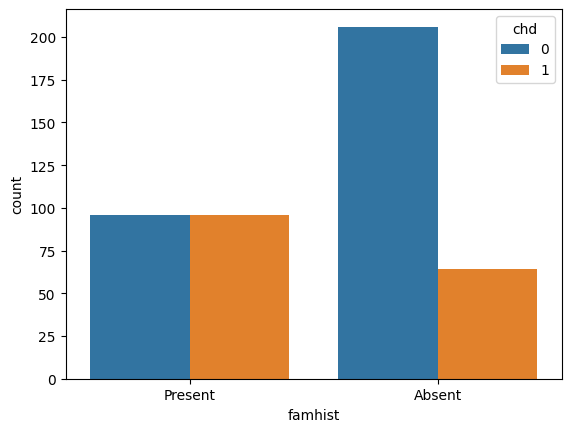

In [15]:
#plot familyhist and chd
sn.countplot(x = 'famhist', hue = 'chd', data = chd_df)

Univariate
- When numerical then it is histogram, KDE (density plot), Boxplot
- When categorical then Barplot

Bivariate
- NN - scatter plot, heatmap
- NC - Overlapped plot, Box plot
- CC - Grouped bar plot, stacked bar graph

<Axes: xlabel='tobacco', ylabel='Density'>

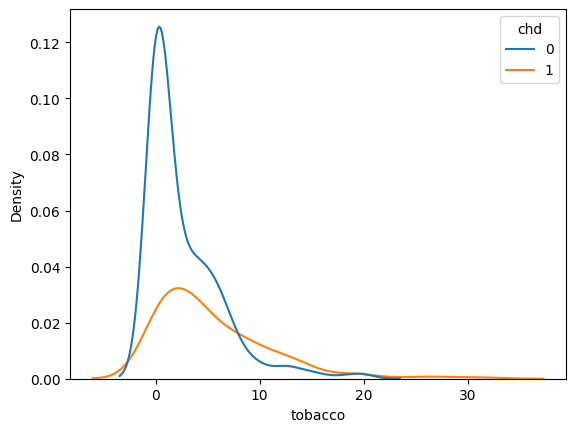

In [16]:
#Plot between tobbacco and chd where chd is categorical - overlap histogram
sn.kdeplot(x = 'tobacco', hue = 'chd', data = chd_df)

In [17]:
#Perform t test between tobacco and chd to check if avg of tobbacco
from scipy.stats import ttest_ind
ttest_ind(chd_df[chd_df['chd'] == 0]['tobacco'], chd_df[chd_df['chd'] == 1]['tobacco'])

TtestResult(statistic=-6.737983717964519, pvalue=4.8158425716055754e-11, df=460.0)

Hence, Tobacco is statistically significant when deciding CHD

<Axes: xlabel='age'>

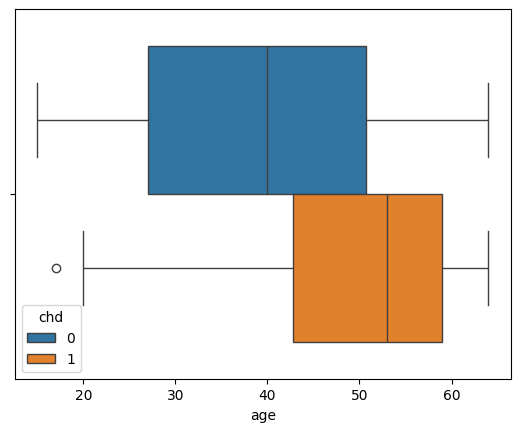

In [18]:
#Plot between age and chd
sn.boxplot(x = 'age', hue = 'chd', data = chd_df)

Hence, age likely to affect chances of getting CHD

<Axes: xlabel='alcohol', ylabel='obesity'>

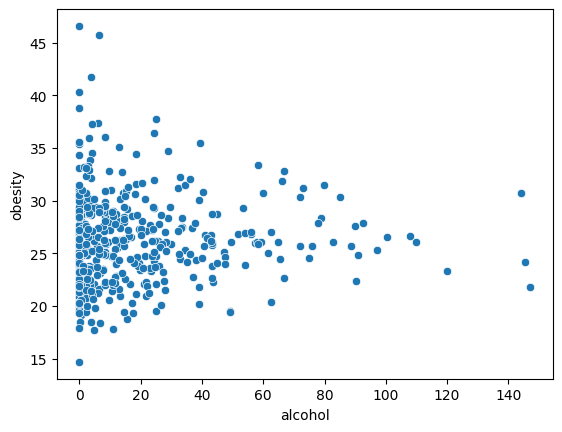

In [19]:
#Plot alcohol and obesity
sn.scatterplot(x = 'alcohol', y = 'obesity', data = chd_df)

<Axes: xlabel='alcohol', ylabel='obesity'>

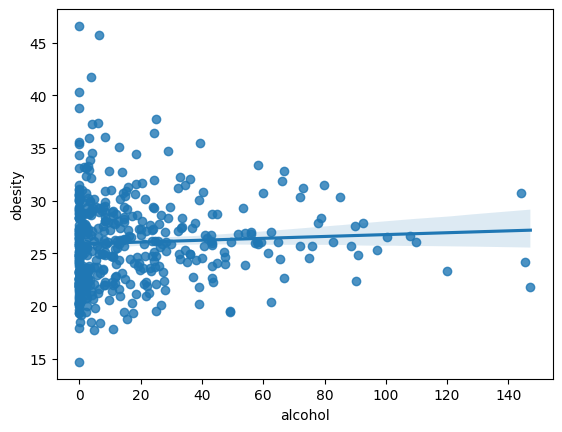

In [20]:
#Reg plot between alcohol and obesity
sn.regplot(x = 'alcohol', y = 'obesity', data = chd_df)

In [21]:
#Pearson correlation between alcohol abd obesity
cor_mat = chd_df[['alcohol', 'obesity','tobacco','age','ldl','adiposity', 'sbp']].corr()

- Very small correlation between alcohol and obesity around 5%
- Age and tobacco has 45% correlation
- Age and adiposity has 62%

<Axes: >

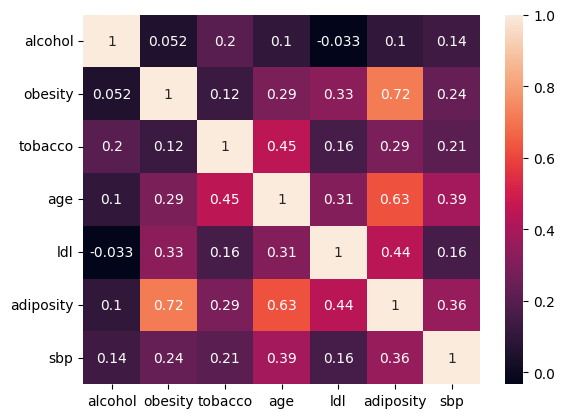

In [22]:
#Plot correlation matrix
sn.heatmap(cor_mat, annot = True)

<Axes: xlabel='sbp', ylabel='Density'>

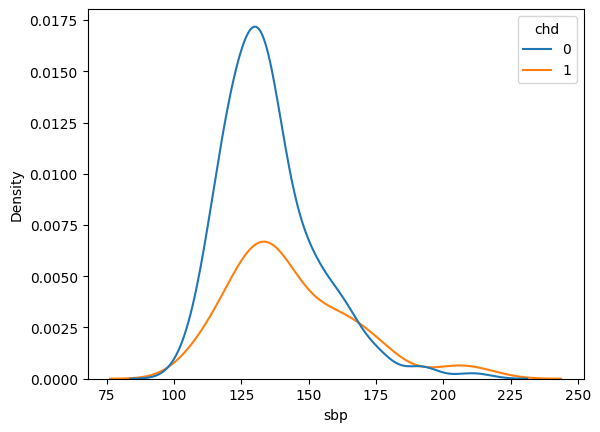

In [23]:
# Plot between sbp and chd
sn.kdeplot(x = 'sbp', hue = 'chd', data = chd_df)

<Axes: xlabel='sbp', ylabel='obesity'>

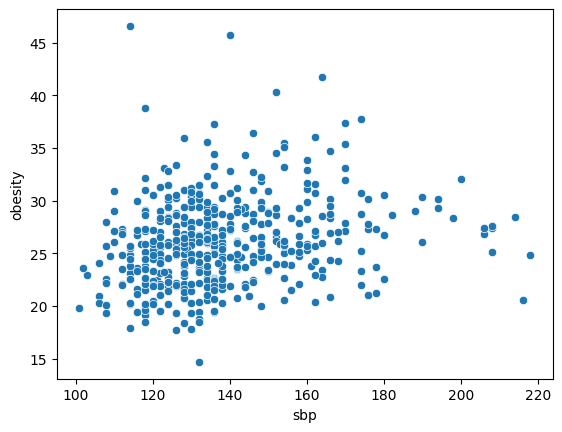

In [24]:
# Plot between sbp and obesity
sn.scatterplot(x = 'sbp', y = 'obesity', data = chd_df)

<Axes: xlabel='obesity'>

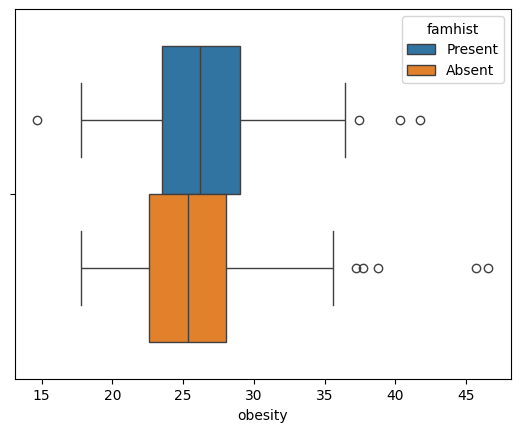

In [25]:
# Plot between obesity(numeric) and famhist (categorical)
sn.boxplot(x = 'obesity', hue = 'famhist', data = chd_df)

## Model building

In [26]:
#Create dummy variable for categorical variable famhist
encoded_chd_df = pd.get_dummies(chd_df, columns = ['famhist'],
                                drop_first = True,
                                dtype=int)

In [27]:
encoded_chd_df.head(5)

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,chd,famhist_Present
row.names,,,,,,,,,,
1,160,12.00,5.73,23.11,49,25.30,97.20,52,1,1
2,144,0.01,4.41,28.61,55,28.87,2.06,63,1,0
3,118,0.08,3.48,32.28,52,29.14,3.81,46,0,1
4,170,7.50,6.41,38.03,51,31.99,24.26,58,1,1
5,134,13.60,3.50,27.78,60,25.99,57.34,49,1,1


In [28]:
#create train test split
from sklearn.model_selection import train_test_split

In [29]:
#Create x_features
x_features = encoded_chd_df.drop('chd', axis = 1)

In [30]:
#List for best_param - feature selection
X_features = list(encoded_chd_df.columns)
X_features.remove('chd')

In [31]:
#create x train, x test, y train, y test
X_train, X_test, y_train, y_test = train_test_split(x_features,
                                                    encoded_chd_df['chd'],
                                                    test_size = 0.2,
                                                    random_state = 100)

In [32]:
X_train.shape

(369, 9)

In [33]:
X_test.shape

(93, 9)

## Build Decision Tree Model

In [34]:
#Build decision tree
from sklearn.tree import DecisionTreeClassifier

In [35]:
#build tree
tree = DecisionTreeClassifier(max_depth = 5, criterion='gini')

In [36]:
tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5)

In [37]:
y_pred = tree.predict(X_test)

In [38]:
y_df = pd.DataFrame({"actual": y_test,
                     "predicted": y_pred})

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test, y_pred)

0.6451612903225806

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [42]:
print(classification_report(y_df.actual, y_df.predicted))

              precision    recall  f1-score   support

           0       0.67      0.78      0.72        55
           1       0.59      0.45      0.51        38

    accuracy                           0.65        93
   macro avg       0.63      0.61      0.62        93
weighted avg       0.64      0.65      0.63        93



In [43]:
pred_probs = tree.predict_proba(X_test)
y_df['pred_probs'] = pred_probs[:, 1]

In [44]:
y_df = pd.DataFrame({"actual": y_test,
                          "predicted": y_pred,
                          "pred_probs": pred_probs[:, 1]})

In [45]:
y_df

,actual,predicted,pred_probs
row.names,,,
304,0,0,0.120000
426,1,0,0.031579
237,0,1,0.782609
274,0,0,0.031579
362,1,1,0.600000
...,...,...,...
226,0,0,0.277778
437,0,0,0.031579
34,1,0,0.028571


<Axes: xlabel='pred_probs', ylabel='Density'>

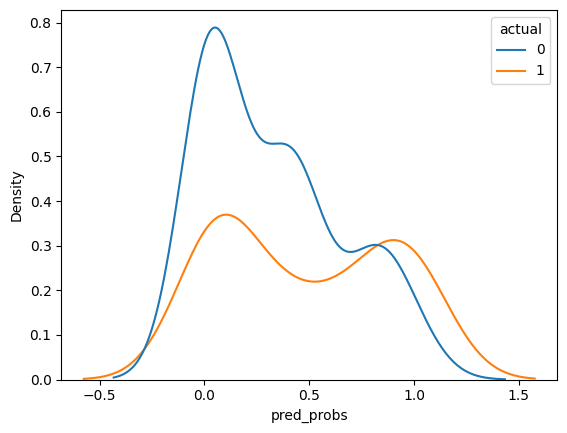

In [46]:
#To check how well the probabilities are
sn.kdeplot(x = 'pred_probs', hue = 'actual', data = y_df)

In [47]:
#roc_auc score and curve
from sklearn.metrics import roc_auc_score,RocCurveDisplay

In [48]:
roc_auc_score(y_df.actual, y_df.pred_probs)

0.6368421052631579

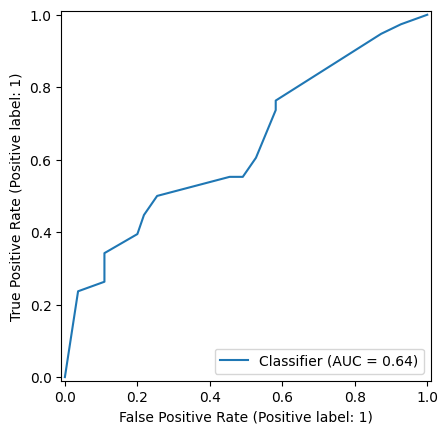

In [49]:
#display ROC curve
RocCurveDisplay.from_predictions(y_df.actual, y_df.pred_probs);

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [51]:
cm = confusion_matrix(y_df.actual, y_df.predicted, labels=[1,0])

In [52]:
cm_plot = ConfusionMatrixDisplay(cm, display_labels=['chd', 'No chd'])

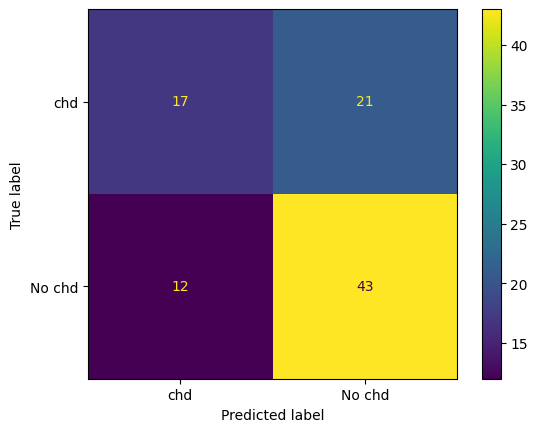

In [53]:
cm_plot.plot();

## Grid Search

In [54]:
from sklearn.model_selection import GridSearchCV

In [55]:
params = {'max_depth': range(3, 15, 2),
          'criterion': ['gini', 'entropy']}

In [56]:
grid_v1 = GridSearchCV(estimator = DecisionTreeClassifier(),
                     param_grid = params,
                     cv = 5,
                       scoring = 'recall')

In [57]:
grid_v1.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(3, 15, 2)},
             scoring='recall')

In [58]:
grid_results = pd.DataFrame(grid_v1.cv_results_)

In [59]:
grid_results[grid_results.rank_test_score < 10]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
1,0.005398,0.000290,0.006473,0.000331,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.32,0.48,0.458333,0.416667,0.375000,0.410000,0.057629,7
2,0.005839,0.001261,0.006468,0.001420,gini,7,"{'criterion': 'gini', 'max_depth': 7}",0.40,0.40,0.416667,0.416667,0.583333,0.443333,0.070396,5
3,0.004131,0.000076,0.004039,0.000181,gini,9,"{'criterion': 'gini', 'max_depth': 9}",0.48,0.52,0.375000,0.500000,0.583333,0.491667,0.067856,2
4,0.004190,0.000284,0.004827,0.001136,gini,11,"{'criterion': 'gini', 'max_depth': 11}",0.40,0.56,0.375000,0.416667,0.541667,0.458667,0.076633,4
5,0.004013,0.000064,0.003890,0.000018,gini,13,"{'criterion': 'gini', 'max_depth': 13}",0.48,0.48,0.416667,0.500000,0.583333,0.492000,0.053608,1
8,0.004190,0.000036,0.003864,0.000096,entropy,7,"{'criterion': 'entropy', 'max_depth': 7}",0.44,0.52,0.625000,0.333333,0.250000,0.433667,0.132591,6
9,0.004383,0.000070,0.004034,0.000229,entropy,9,"{'criterion': 'entropy', 'max_depth': 9}",0.44,0.44,0.333333,0.333333,0.416667,0.392667,0.049189,9
10,0.004501,0.000258,0.004071,0.000346,entropy,11,"{'criterion': 'entropy', 'max_depth': 11}",0.40,0.44,0.625000,0.458333,0.375000,0.459667,0.087695,3
11,0.005095,0.000799,0.004529,0.000784,entropy,13,"{'criterion': 'entropy', 'max_depth': 13}",0.44,0.44,0.333333,0.416667,0.375000,0.401000,0.041333,8


In [60]:
grid_results[['param_criterion',
              'param_max_depth',
              'mean_test_score',
              'std_test_score',
              'rank_test_score']].sort_values('rank_test_score', ascending = True)[0:10]

,param_criterion,param_max_depth,mean_test_score,std_test_score,rank_test_score
5,gini,13,0.492000,0.053608,1
3,gini,9,0.491667,0.067856,2
10,entropy,11,0.459667,0.087695,3
4,gini,11,0.458667,0.076633,4
2,gini,7,0.443333,0.070396,5
8,entropy,7,0.433667,0.132591,6
1,gini,5,0.410000,0.057629,7
11,entropy,13,0.401000,0.041333,8
9,entropy,9,0.392667,0.049189,9
6,entropy,3,0.383000,0.191312,10


In [61]:
grid_v1.best_params_

{'criterion': 'gini', 'max_depth': 13}

In [62]:
grid_v1.best_score_

0.492

In [63]:
pd.DataFrame(grid_v1.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005835,0.001457,0.007178,0.001451,gini,3,"{'criterion': 'gini', 'max_depth': 3}",0.24,0.40,0.333333,0.333333,0.083333,0.278000,0.109861,12
1,0.005398,0.000290,0.006473,0.000331,gini,5,"{'criterion': 'gini', 'max_depth': 5}",0.32,0.48,0.458333,0.416667,0.375000,0.410000,0.057629,7
2,0.005839,0.001261,0.006468,0.001420,gini,7,"{'criterion': 'gini', 'max_depth': 7}",0.40,0.40,0.416667,0.416667,0.583333,0.443333,0.070396,5
3,0.004131,0.000076,0.004039,0.000181,gini,9,"{'criterion': 'gini', 'max_depth': 9}",0.48,0.52,0.375000,0.500000,0.583333,0.491667,0.067856,2
4,0.004190,0.000284,0.004827,0.001136,gini,11,"{'criterion': 'gini', 'max_depth': 11}",0.40,0.56,0.375000,0.416667,0.541667,0.458667,0.076633,4
5,0.004013,0.000064,0.003890,0.000018,gini,13,"{'criterion': 'gini', 'max_depth': 13}",0.48,0.48,0.416667,0.500000,0.583333,0.492000,0.053608,1
6,0.003521,0.000450,0.004519,0.000542,entropy,3,"{'criterion': 'entropy', 'max_depth': 3}",0.60,0.44,0.541667,0.250000,0.083333,0.383000,0.191312,10
7,0.003910,0.000125,0.004006,0.000348,entropy,5,"{'criterion': 'entropy', 'max_depth': 5}",0.40,0.40,0.458333,0.250000,0.208333,0.343333,0.096523,11
8,0.004190,0.000036,0.003864,0.000096,entropy,7,"{'criterion': 'entropy', 'max_depth': 7}",0.44,0.52,0.625000,0.333333,0.250000,0.433667,0.132591,6
9,0.004383,0.000070,0.004034,0.000229,entropy,9,"{'criterion': 'entropy', 'max_depth': 9}",0.44,0.44,0.333333,0.333333,0.416667,0.392667,0.049189,9


## Significant variables

In [64]:
grid_v1.best_estimator_.feature_importances_

array([0.11350642, 0.10380874, 0.20822343, 0.11167017, 0.07867851,
       0.05415625, 0.09328928, 0.17825718, 0.05841003])

In [65]:
importance_df = pd.DataFrame({'feature': X_features,
                              'importance': grid_v1.best_estimator_.feature_importances_})

In [66]:
importance_df = importance_df.sort_values('importance', ascending = False)
importance_df

,feature,importance
2,ldl,0.208223
7,age,0.178257
0,sbp,0.113506
3,adiposity,0.111670
1,tobacco,0.103809
6,alcohol,0.093289
4,typea,0.078679
8,famhist_Present,0.058410
5,obesity,0.054156


## Random Forest Model

In [67]:
#Build Random Forest Model
from sklearn.ensemble import RandomForestClassifier


Random Forest Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

           0       0.67      0.85      0.75        55
           1       0.65      0.39      0.49        38

    accuracy                           0.67        93
   macro avg       0.66      0.62      0.62        93
weighted avg       0.66      0.67      0.65        93

Random Forest ROC AUC Score: 0.7258373205741627


,feature,importance
7,age,0.205115
1,tobacco,0.156480
2,ldl,0.152364
3,adiposity,0.108858
8,famhist_Present,0.099222
0,sbp,0.079188
5,obesity,0.077535
4,typea,0.074697
6,alcohol,0.046539


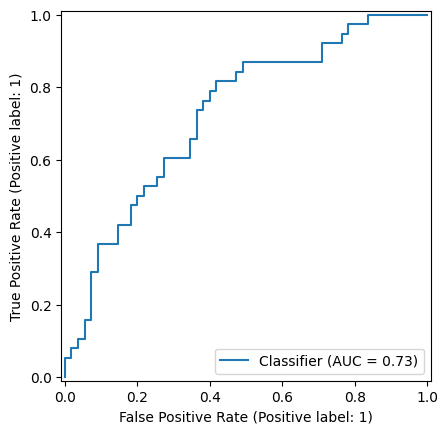

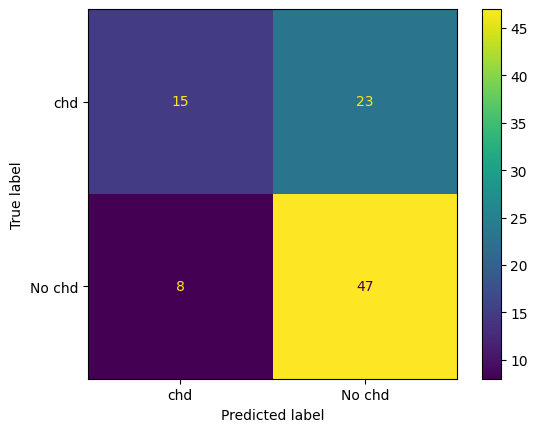

In [68]:
# prompt: Random forest model same as decision tree built before

#Build Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100,
                                  max_depth=5,
                                  random_state=100,
                                  criterion='gini',
                                  max_features = 'sqrt')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf}")
print(classification_report(y_test, y_pred_rf))

# Predict probabilities
pred_probs_rf = rf_model.predict_proba(X_test)

# Create DataFrame for analysis
y_df_rf = pd.DataFrame({"actual": y_test,
                          "predicted": y_pred_rf,
                          "pred_probs": pred_probs_rf[:, 1]})

# ROC AUC Score and Curve
roc_auc_rf = roc_auc_score(y_df_rf.actual, y_df_rf.pred_probs)
print(f"Random Forest ROC AUC Score: {roc_auc_rf}")
RocCurveDisplay.from_predictions(y_df_rf.actual, y_df_rf.pred_probs);

# Confusion Matrix
cm_rf = confusion_matrix(y_df_rf.actual, y_df_rf.predicted, labels=[1,0])
cm_plot_rf = ConfusionMatrixDisplay(cm_rf, display_labels=['chd', 'No chd'])
cm_plot_rf.plot();

# Feature Importance
importance_df_rf = pd.DataFrame({'feature': X_features,
                              'importance': rf_model.feature_importances_})
importance_df_rf = importance_df_rf.sort_values('importance', ascending = False)
importance_df_rf

In [69]:
from sklearn.model_selection import cross_val_score

In [70]:
scores = cross_val_score(rf_model, X_train, y_train, cv = 5, scoring = 'recall')

In [71]:
scores.std()

0.058322856201969

In [72]:
scores.mean()

0.4013333333333334

##Boosting

In [73]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression

In [74]:
adaboost = AdaBoostClassifier(estimator = LogisticRegression(max_iter = 1000),
                              n_estimators = 50,
                              learning_rate = 0.4)

In [75]:
adaboost.fit(X_train, y_train)

AdaBoostClassifier(estimator=LogisticRegression(max_iter=1000),
                   learning_rate=0.4)

In [76]:
y_pred = adaboost.predict(X_test)

In [77]:
from sklearn.metrics import classification_report

In [79]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.82      0.75        55
           1       0.64      0.47      0.55        38

    accuracy                           0.68        93
   macro avg       0.67      0.65      0.65        93
weighted avg       0.67      0.68      0.67        93



For multiclass classification - performance metrics we looks at MCC and kappa score

##Stacking

In [80]:
from sklearn.ensemble import StackingClassifier

In [82]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

In [81]:
StackingClassifier?

In [84]:
base_estimator = [('LR', LogisticRegression(max_iter = 1000)),
                  ('DT', DecisionTreeClassifier(max_depth = 5, criterion = 'gini')),
                  ('KNN', KNeighborsClassifier(n_neighbors = 5))]

In [85]:
meta_estimator = LogisticRegression(max_iter = 1000)

In [86]:
stacking = StackingClassifier(estimators = base_estimator,
                             final_estimator = meta_estimator)

In [87]:
stacking.fit(X_train, y_train)

StackingClassifier(estimators=[('LR', LogisticRegression(max_iter=1000)),
                               ('DT', DecisionTreeClassifier(max_depth=5)),
                               ('KNN', KNeighborsClassifier())],
                   final_estimator=LogisticRegression(max_iter=1000))

In [88]:
y_pred = stacking.predict(X_test)

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.85      0.76        55
           1       0.67      0.42      0.52        38

    accuracy                           0.68        93
   macro avg       0.67      0.64      0.64        93
weighted avg       0.68      0.68      0.66        93



In [90]:
max_iter?

Object `max_iter` not found.
